In [ ]:
from transformers import AutoModelForCausalLM, AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer, DataCollatorWithPadding
from datasets import Dataset
import torch
import pandas as pd
from datasets import Dataset
import numpy as np
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

In [ ]:
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.padding_side = "left"

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16,
    device_map="auto"
)
model.eval()

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((1536,), eps=1e-06)
    (rotar

In [ ]:
df = pd.read_csv("test_grnti.csv")

selected_classes = [
    "Энергетика",
    "Языкознание",
    "Психология",
    "Философия",
    "Биология",
    "Геология",
    "Химия",
    "Транспорт",
    "Физика",
    "Математика"
]

clinc_classes = [
    "баланс",
    "бензин",
    "рецепт",
    "музыка",
    "пробки",
    "перевод",
    "погода",
    "налоги",
    "вакцины",
    "напоминание"
]

def clean_data(dataframe, classes):
    dataframe['text'] = dataframe['text'].astype(str).str.strip()
    dataframe['label'] = dataframe['label'].astype(str).str.strip()

    initial_shape = dataframe.shape[0]
    dataframe = dataframe[dataframe['label'].isin(classes)].copy()

    print(f"Удалено строк с неизвестными классами: {initial_shape - dataframe.shape[0]}")
    return dataframe

df_cleaned = clean_data(df, selected_classes)
test_10 = Dataset.from_pandas(df_cleaned)

Удалено строк с неизвестными классами: 0


In [ ]:
print(df)

         id                                               text      label
0    178587  ВЫСОКОВОЛЬТНЫЕ ЯВЛЕНИЯ В РАСПЛАВЛЕННЫХ ХЛОРИДН...      Химия
1     61924  Каталитическое карбонилирование α-олефинов в п...      Химия
2    165778  ВЛИЯНИЕ ТЕМПЕРАТУРЫ И КОНЦЕНТРАЦИИ НА ГИДРАТАЦ...      Химия
3    126942  ОПРЕДЕЛЕНИЕ КОЭФФИЦИЕНТОВ ДИФФУЗИИ АМЕРИЦИЯ И ...      Химия
4     54173  ОБЩЕЕ ПРЕДСТАВЛЕНИЕ О НУКЛЕАЗАХ ИЗ ЯДА ЗМЕЙ: Д...      Химия
..      ...                                                ...        ...
995  118131  Демокрит и дата падения Трои. В статье рассмат...  Философия
996  181970  ФИЛОСОФИЯ ИСТОРИИ Н.А. БЕРДЯЕВА: ЭКЗИСТЕНЦИАЛЬ...  Философия
997   47446  Проблема императивности в этике Аристотеля. Це...  Философия
998  196697  Тактика вне стратегии. Военно-политическая раб...  Философия
999  165443  ПО ТУ СТОРОНУ ЧЕЛОВЕЧЕСКОГО? (К 110-летию Варл...  Философия

[1000 rows x 3 columns]


In [ ]:
def build_prompt(text, class_list):
    classes_str = "\n".join([f"- {c}" for c in selected_classes])
    return (
        "Ниже приведёна аннотация научной статьи.\n\n"
        f"Текст:\n{text}\n\n"
        "Выбери одну категорию из списка, к которой относится статья:\n"
        f"{classes_str}\n\n"
        "Ответ:"
    )
# Эмпирика показывает, что более развёрнутые промпты работают хуже


test_dataset = test_10
class_token_ids = []
for cl in selected_classes:
    tid = tokenizer.encode(" " + cl, add_special_tokens=False)[0]
    class_token_ids.append(tid)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
def get_uncertainty_metrics(example):
    prompt = build_prompt(example["text"], selected_classes)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits[0, -1, :]

    # Берем логиты только наших 10 классов
    target_logits = logits[class_token_ids]

    target_probs = torch.nn.functional.softmax(target_logits, dim=-1).cpu().numpy()

    # Рассчитываем лог-вероятности (для стабильной энтропии)
    # Это предотвращает появление log(0)
    target_log_probs = torch.nn.functional.log_softmax(target_logits, dim=-1).cpu().numpy()

    pred_idx = np.argmax(target_probs)
    max_prob = target_probs[pred_idx]

    # Стабильная энтропия: используем сумму (p * log p)
    # Добавляем маленькую дельту для безопасности
    entropy = -np.sum(target_probs * target_log_probs)

    # Проверка на NaN
    if np.isnan(entropy):
        entropy = 0.0

    perplexity = np.exp(entropy)

    sorted_probs = np.sort(target_probs)[::-1]
    margin = sorted_probs[0] - sorted_probs[1]

    return {
        "pred_idx": int(pred_idx),
        "true_idx": selected_classes.index(example["label"]),
        "max_prob": float(max_prob),
        "entropy": float(entropy),
        "perplexity": float(perplexity),
        "margin": float(margin)
    }

In [ ]:
final_results = []
for row in tqdm(test_dataset):
    res = get_uncertainty_metrics(row)
    final_results.append(res)

res_df = pd.DataFrame(final_results)
y_error = (res_df['pred_idx'] != res_df['true_idx']).astype(int)

# Проверка на всякий случай
if res_df.isnull().values.any():
    print("Внимание: NaN все еще есть! Очищаем...")
    res_df = res_df.dropna()

print("\n")
print(f"AUROC (Entropy): {roc_auc_score(y_error, res_df['entropy']):.4f}")
print(f"AUROC (Margin): {roc_auc_score(y_error, -res_df['margin']):.4f}") # инвертируем, так как большая маржа = меньше ошибок
print(f"AUROC (Confidence): {roc_auc_score(y_error, -res_df['max_prob']):.4f}")
print(f"AUROC (Perplexity): {roc_auc_score(y_error, res_df['perplexity']):.4f}")

100%|██████████| 1000/1000 [01:43<00:00,  9.67it/s]



AUROC (Entropy): 0.8197
AUROC (Margin): 0.7783
AUROC (Confidence): 0.8125
AUROC (Perplexity): 0.8197


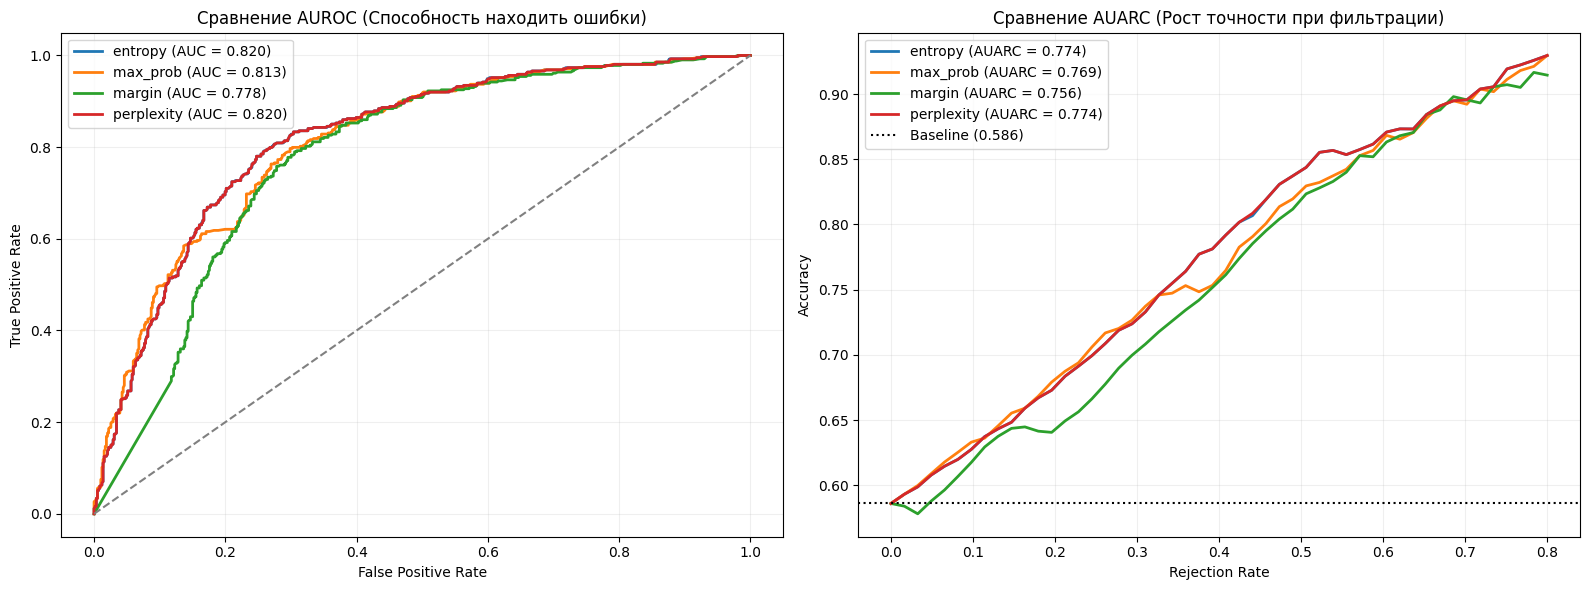

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_all_metrics(res_df):
    metrics = ['entropy', 'max_prob', 'margin', 'perplexity']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    is_correct = (res_df['pred_idx'] == res_df['true_idx']).values
    y_error = (~is_correct).astype(int)
    baseline_acc = np.mean(is_correct)

    plt.figure(figsize=(16, 6))

    # AUROC
    plt.subplot(1, 2, 1)
    for metric, color in zip(metrics, colors):
        scores = res_df[metric].values
        # Инвертируем те, где меньше = лучше
        if metric in ['entropy', 'perplexity']:
            scores_for_roc = scores
        else:
            scores_for_roc = -scores

        fpr, tpr, _ = roc_curve(y_error, scores_for_roc)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2, label=f'{metric} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Сравнение AUROC (Способность находить ошибки)')
    plt.legend()
    plt.grid(alpha=0.2)

    # AUARC
    plt.subplot(1, 2, 2)
    rejection_rates = np.linspace(0, 0.8, 50) # Отсеиваем до 80% данных

    for metric, color in zip(metrics, colors):
        scores = res_df[metric].values
        # Сортируем: сначала самые уверенные
        if metric in ['entropy', 'perplexity']:
            sorted_indices = np.argsort(scores) # Меньше значение -> выше уверенность
        else:
            sorted_indices = np.argsort(scores)[::-1] # Больше значение -> выше уверенность

        sorted_correct = is_correct[sorted_indices]

        accuracies = []
        for rate in rejection_rates:
            n_keep = int(len(sorted_correct) * (1 - rate))
            acc = np.mean(sorted_correct[:n_keep]) if n_keep > 0 else 0
            accuracies.append(acc)

        auarc_val = auc(rejection_rates, accuracies) / 0.8 # Нормируем на макс. rejection
        plt.plot(rejection_rates, accuracies, color=color, lw=2, label=f'{metric} (AUARC = {auarc_val:.3f})')

    plt.axhline(y=baseline_acc, color='black', linestyle=':', label=f'Baseline ({baseline_acc:.3f})')
    plt.xlabel('Rejection Rate')
    plt.ylabel('Accuracy')
    plt.title('Сравнение AUARC (Рост точности при фильтрации)')
    plt.legend()
    plt.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

plot_all_metrics(res_df)

In [ ]:
from sklearn.metrics import auc

def print_final_metrics(df):
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['entropy', 'max_prob', 'margin', 'perplexity'])

    metrics = ['entropy', 'max_prob', 'margin', 'perplexity']
    is_correct = (df['pred_idx'] == df['true_idx']).values
    y_error = (~is_correct).astype(int)

    rejection_rates = np.linspace(0, 0.8, 50)

    print("="*40)
    print(f"{'Метрика':<15} | {'AUROC':<10} | {'AUARC':<10}")
    print("-"*40)

    results_summary = {}

    for metric in metrics:
        scores = df[metric].values

        # AUROC
        if metric in ['entropy', 'perplexity']:
            scores_for_roc = scores
        else:
            scores_for_roc = -scores

        fpr, tpr, _ = roc_curve(y_error, scores_for_roc)
        auroc_val = auc(fpr, tpr)

        # AUARC
        if metric in ['entropy', 'perplexity']:
            sorted_indices = np.argsort(scores)
        else:
            sorted_indices = np.argsort(scores)[::-1]

        sorted_correct = is_correct[sorted_indices]

        accuracies = []
        for rate in rejection_rates:
            n_keep = int(len(sorted_correct) * (1 - rate))
            acc = np.mean(sorted_correct[:n_keep]) if n_keep > 0 else 0
            accuracies.append(acc)
        # Нормируем на 0.8 (максимальный rejection rate в нашем цикле)
        auarc_val = auc(rejection_rates, accuracies) / 0.8

        print(f"{metric:<15} | {auroc_val:.4f}     | {auarc_val:.4f}")
        results_summary[metric] = {'auroc': auroc_val, 'auarc': auarc_val}

    print("="*40)
    return results_summary

stats = print_final_metrics(res_df)

Метрика         | AUROC      | AUARC     
----------------------------------------
entropy         | 0.8197     | 0.7736
max_prob        | 0.8125     | 0.7686
margin          | 0.7783     | 0.7558
perplexity      | 0.8197     | 0.7736
